In [ ]:
!pip install -q gdown

In [ ]:
import gdown
import os
import zipfile
import tensorflow as tf
from tensorflow.keras import callbacks
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
#Descargar el dataset en formato ZIP del Drive y descomprimirlo
# https://drive.google.com/file/d/1vMNYIJGRQXGOMwl6pl2yFfEbwMPBqs0x/view?usp=sharing
file_id = "1vMNYIJGRQXGOMwl6pl2yFfEbwMPBqs0x"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url,"dataset_augmented.zip",quiet=False)

with zipfile.ZipFile("dataset_augmented.zip",'r') as zip_ref:
  zip_ref.extractall("/content/dataset_augmented")

Downloading...
From (original): https://drive.google.com/uc?id=1vMNYIJGRQXGOMwl6pl2yFfEbwMPBqs0x
From (redirected): https://drive.google.com/uc?id=1vMNYIJGRQXGOMwl6pl2yFfEbwMPBqs0x&confirm=t&uuid=14be6dc9-36c0-4865-aa5d-86ea5cebba3c
To: /content/dataset_augmented.zip
100%|██████████| 580M/580M [00:08<00:00, 65.3MB/s]


In [ ]:
#Cargar los datasets de entrenamiento,validación y test
base_path = "/content/dataset_augmented/dataset_augmented"

train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")
test_path = os.path.join(base_path, "test")

print("Clases en TRAIN:")
print(os.listdir(train_path))

print("\nClases en VALIDATION:")
print(os.listdir(val_path))

print("\nClases en TEST:")
print(os.listdir(test_path))

img_size = (224,224)
batch = 16

train_df = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch)
val_df = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=img_size,
    batch_size=batch)
test_df = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch)

class_names = train_df.class_names

print("\nClases detectadas:")
print(train_df.class_names)

train_df = train_df.prefetch(tf.data.AUTOTUNE)
val_df = val_df.prefetch(tf.data.AUTOTUNE)
test_df = test_df.prefetch(tf.data.AUTOTUNE)


Clases en TRAIN:
['ala_fija', 'no_uav', 'helicoptero', 'multirotor']

Clases en VALIDATION:
['ala_fija', 'no_uav', 'helicoptero', 'multirotor']

Clases en TEST:
['ala_fija', 'no_uav', 'helicoptero', 'multirotor']
Found 2100 files belonging to 4 classes.
Found 152 files belonging to 4 classes.
Found 148 files belonging to 4 classes.

Clases detectadas:
['ala_fija', 'helicoptero', 'multirotor', 'no_uav']


In [ ]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(0.05,0.05)
])


model = tf.keras.Sequential([
    tf.keras.Input(shape=(224,224,3)),
    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(class_names),activation='softmax')
    ])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,268 (1012.77 KB)

 Trainable params: 258,564 (1010.02 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
early_stop = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint('mejor_uav_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1)
]


history = model.fit(
    train_df,
    validation_data=val_df,
    epochs=60,
    callbacks=early_stop
)

test_loss,test_acc = model.evaluate(test_df)
print("Test accuracy:",test_acc)

Epoch 1/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3686 - loss: 1.3901
Epoch 1: val_loss improved from None to 1.70276, saving model to mejor_uav_model.keras

Epoch 1: finished saving model to mejor_uav_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 427s 3s/step - accuracy: 0.3924 - loss: 1.3288 - val_accuracy: 0.2500 - val_loss: 1.7028 - learning_rate: 5.0000e-04
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4731 - loss: 1.2199
Epoch 2: val_loss did not improve from 1.70276
132/132 ━━━━━━━━━━━━━━━━━━━━ 421s 3s/step - accuracy: 0.4748 - loss: 1.2091 - val_accuracy: 0.2500 - val_loss: 2.5274 - learning_rate: 5.0000e-04
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4897 - loss: 1.1626
Epoch 3: val_loss did not improve from 1.70276
132/132 ━━━━━━━━━━━━━━━━━━━━ 410s 3s/step - accuracy: 0.5038 - loss: 1.1463 - val_accuracy: 0.2632 - val_loss: 1.8565 - learning_rate: 5.0000e-04
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5275

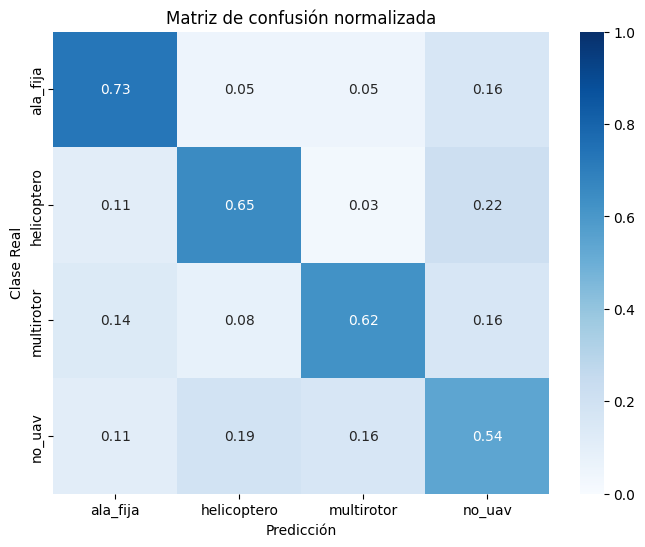

Classification report:
              precision    recall  f1-score   support

    ala_fija       0.68      0.73      0.70        37
 helicoptero       0.67      0.65      0.66        37
  multirotor       0.72      0.62      0.67        37
      no_uav       0.50      0.54      0.52        37

    accuracy                           0.64       148
   macro avg       0.64      0.64      0.64       148
weighted avg       0.64      0.64      0.64       148



In [ ]:
y_true = []
y_pred =[]

for images, labels in test_df:
    predictions = model.predict(images,verbose=0)
    pred_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

matriz_conf = confusion_matrix(y_true,y_pred,normalize='true')
plt.figure(figsize=(8,6))
sns.heatmap(matriz_conf,annot=True,fmt='.2f',cmap='Blues',vmin=0,vmax=1,xticklabels=class_names,yticklabels=class_names)

plt.xlabel('Predicción')
plt.ylabel('Clase Real')
plt.title('Matriz de confusión normalizada')
plt.show()

print("Classification report:")
print(classification_report(y_true,y_pred,target_names=class_names))


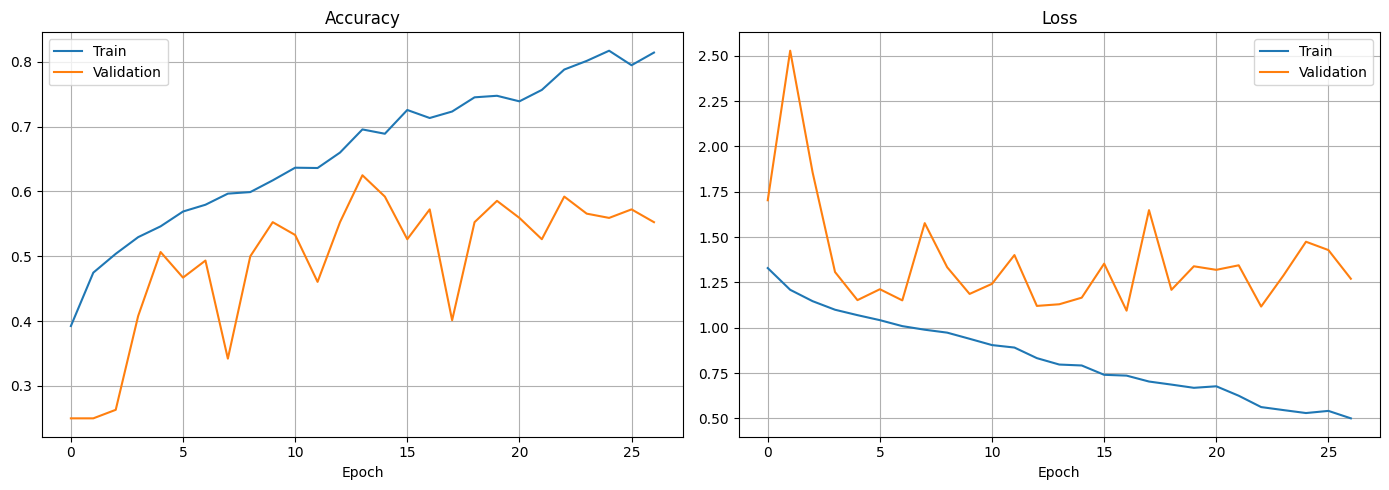

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

# Accuracy
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Validation')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Época')
ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Validation')
ax[1].set_title('Loss')
ax[1].set_xlabel('Época')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()